In [1]:
################################################################
# GREENFIELD AUTOMOTIVE PAINT SHOP PROJECT
# Milestone Delay Prediction - Final Project
#
# Notebook 02: Data Preprocessing and Feature Engineering
#
# In this notebook:
# 1. Outlier detection (IQR + LOF)
# 2. Derive new features (interaction features, date features)
# 3. Encoding (Label / One-Hot)
# 4. Scaling
# 5. Train/test split
# 6. Save processed dataset as pickle for use in Notebook 03
################################################################

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [3]:
df = pd.read_csv('paintshop_milestone_delays.csv',
                 parse_dates=['planned_start', 'planned_finish', 'actual_finish_date'])

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (3565, 26)

First 3 rows:
     task_id                                      activity_name building level axis discipline activity_type  is_outdoor planned_start planned_finish  planned_duration_days  predecessor_count  \
0  ACT-00001                                  Contract Awarding       A1   ---  ---      Other  Construction           0    2024-01-31     2024-02-28                     28                  1   
1  ACT-00002                              Start of Construction       A1   ---  ---      Other  Construction           0    2025-04-11     2025-04-24                     13                  3   
2  ACT-00003  Extension Works - CR Acceptance & Value Cleari...       A1   ---  ---      Other  Construction           0    2025-05-26     2025-06-05                     10                  4   

   is_critical_path  float_days contractor_id  contractor_avg_delay_days contract_type  season material_delivery_status  crew_size  open_rfi_count  open_ncr_count  pending_submittal_coun

In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """Classic helper function used in the bootcamp.
    Compatible with pandas v2+: also detects string dtype as object."""
    # Object/string columns (using pd.api.types for pandas 2+ 'string' dtype)
    is_object = lambda s: pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s)

    cat_cols = [col for col in dataframe.columns if is_object(dataframe[col])]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   not is_object(dataframe[col])]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   is_object(dataframe[col])]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if not is_object(dataframe[col])]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


# Temporarily drop dates and target from typing analysis
df_for_typing = df.drop(columns=['task_id', 'activity_name',
                                  'planned_start', 'planned_finish', 'actual_finish_date',
                                  'delay_days', 'delay_category'])
cat_cols, num_cols, cat_but_car = grab_col_names(df_for_typing)

print("\nCategorical:", cat_cols)
print("\nNumerical:", num_cols)
print("\nCardinal:", cat_but_car)

Observations: 3565
Variables: 19
cat_cols: 13
num_cols: 5
cat_but_car: 1
num_but_cat: 5

Categorical: ['building', 'level', 'discipline', 'activity_type', 'contractor_id', 'contract_type', 'season', 'material_delivery_status', 'is_outdoor', 'is_critical_path', 'open_rfi_count', 'open_ncr_count', 'pending_submittal_count']

Numerical: ['planned_duration_days', 'predecessor_count', 'float_days', 'contractor_avg_delay_days', 'crew_size']

Cardinal: ['axis']


In [5]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * iqr
    low_limit = quartile1 - 1.5 * iqr
    return low_limit, up_limit


def check_outlier(dataframe, col_name, q1=0.25, q3=0.75):
    low, up = outlier_thresholds(dataframe, col_name, q1, q3)
    # Work only on the relevant column as a boolean series, summarize with .any()
    return ((dataframe[col_name] < low) | (dataframe[col_name] > up)).any()


# Check numeric features
print("IQR-based outlier check:")
for col in num_cols:
    print(f"  {col}: {check_outlier(df, col)}")

IQR-based outlier check:
  planned_duration_days: True
  predecessor_count: True
  float_days: True
  contractor_avg_delay_days: True
  crew_size: False


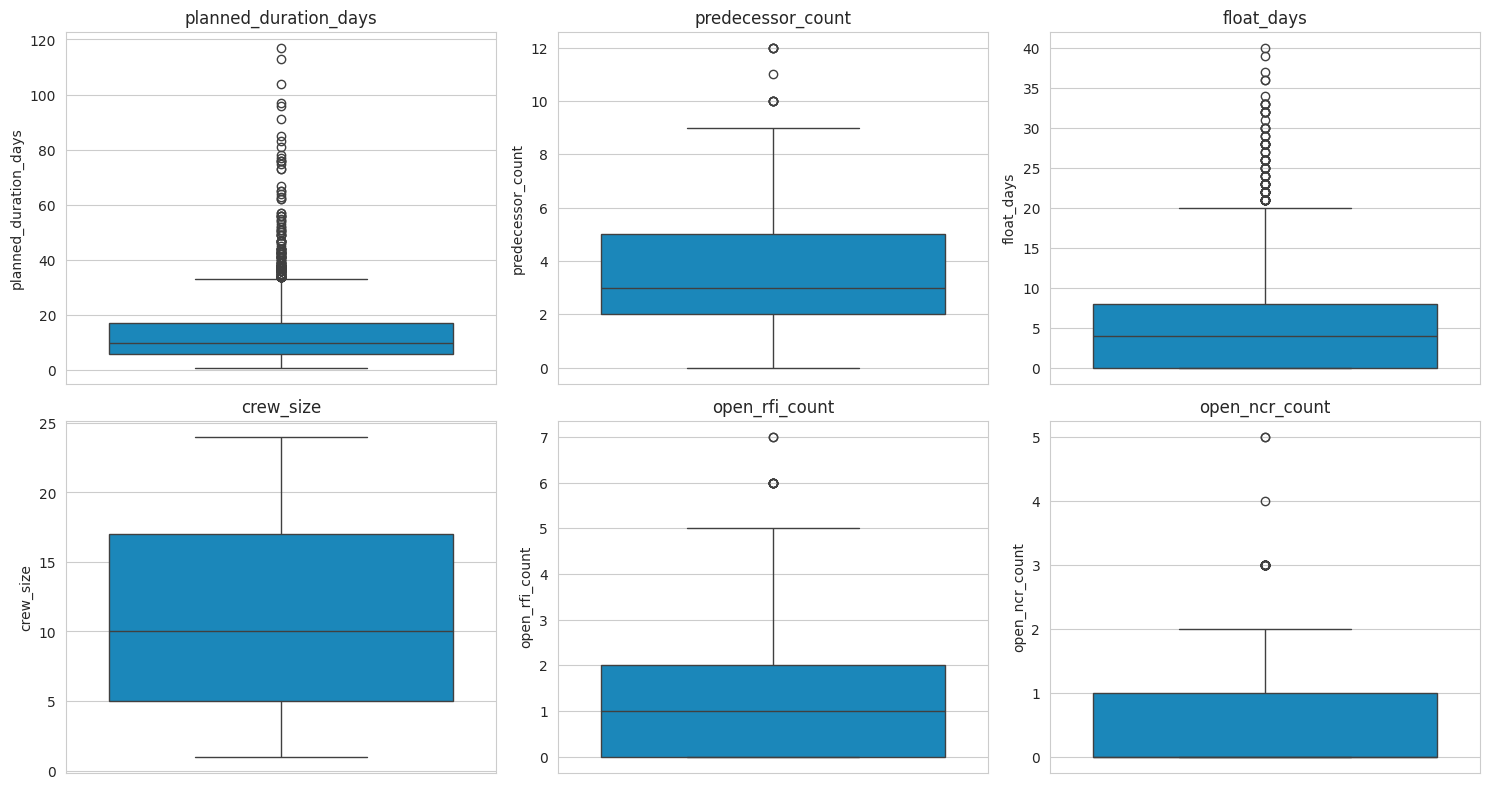

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cols_to_plot = ['planned_duration_days', 'predecessor_count', 'float_days',
                'crew_size', 'open_rfi_count', 'open_ncr_count']
for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=df[col], ax=axes[i], color='#0091D5')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

LOF analysis starting...


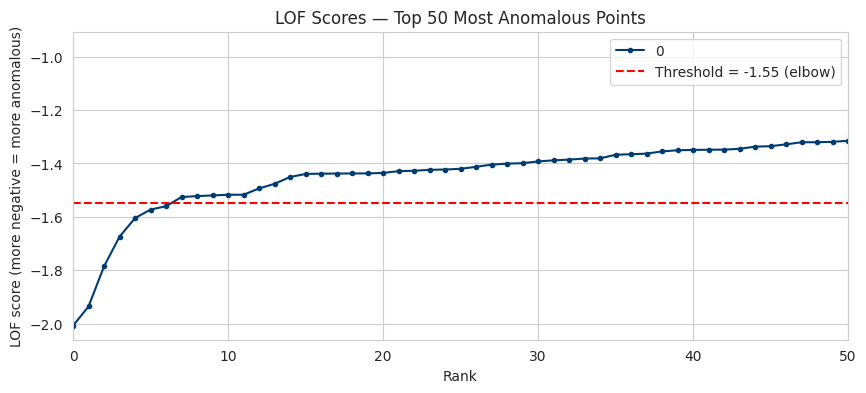


LOF threshold=-1.55 → 7 outliers detected.
That's 0.20% of the total


In [7]:
# LOF (Local Outlier Factor): unlike univariate IQR, it looks at all
# numerical features together to detect outliers based on point density.

print("LOF analysis starting...")
lof_features = num_cols.copy()
lof_data = df[lof_features].copy()

clf = LocalOutlierFactor(n_neighbors=20)
clf.fit_predict(lof_data)
lof_scores = clf.negative_outlier_factor_

# Score distribution (sort and plot)
scores_df = pd.DataFrame(np.sort(lof_scores))
scores_df.plot(stacked=True, xlim=[0, 50], style='.-', figsize=(10, 4),
               color='#003C71', legend=False)
plt.title('LOF Scores — Top 50 Most Anomalous Points')
plt.xlabel('Rank')
plt.ylabel('LOF score (more negative = more anomalous)')
plt.axhline(y=-1.55, color='red', linestyle='--', label='Threshold = -1.55 (elbow)')
plt.legend()
plt.show()

# Threshold value (the "elbow" in the plot)
# Steep drop in ranks 0-5, then flattens → elbow ~ -1.55
threshold = -1.55
n_lof_outliers = (lof_scores < threshold).sum()
print(f"\nLOF threshold={threshold} → {n_lof_outliers} outliers detected.")
print(f"That's {n_lof_outliers/len(df)*100:.2f}% of the total")

In [8]:
# DECISION: We will NOT REMOVE outliers — because:
#   1. Severe delays are the most business-critical class. Losing them would
#      mean losing important signal in the model.
#   2. Tree-based models (CART, RF, LightGBM) are robust to outliers.
#   3. For linear regression, we will use RobustScaler (based on median and IQR).
#
# Therefore we only DETECT and FLAG outliers but don't touch them.

# Add an outlier flag (useful as a feature; the model can use it if helpful)
df['lof_outlier_flag'] = (lof_scores < threshold).astype(int)
print(f"lof_outlier_flag added. Total flagged: {df['lof_outlier_flag'].sum()}")

lof_outlier_flag added. Total flagged: 7


In [9]:
# Features we can derive from planned_start date
df['planned_start_month'] = df['planned_start'].dt.month
df['planned_start_quarter'] = df['planned_start'].dt.quarter
df['planned_start_year'] = df['planned_start'].dt.year
df['planned_start_dayofweek'] = df['planned_start'].dt.dayofweek
# Does the activity start on Monday (first workday of the week)?
df['starts_on_monday'] = (df['planned_start'].dt.dayofweek == 0).astype(int)

# planned_finish may also carry information but is highly correlated with start
# (in our data the schedule planning logic) — skip for now

print("Date features added:")
print(df[['planned_start', 'planned_start_month', 'planned_start_quarter',
          'planned_start_dayofweek', 'starts_on_monday']].head())

Date features added:
  planned_start  planned_start_month  planned_start_quarter  planned_start_dayofweek  starts_on_monday
0    2024-01-31                    1                      1                        2                 0
1    2025-04-11                    4                      2                        4                 0
2    2025-05-26                    5                      2                        0                 1
3    2024-12-02                   12                      4                        0                 1
4    2025-05-05                    5                      2                        0                 1


In [10]:
# These are based on EDA findings:
# - Contractor risk × critical path → very strong together
# - Outdoor × winter → classic combination
# - Duration × predecessor → complexity metric

# 1. Contractor risk × critical path interaction
df['contractor_x_critical'] = df['contractor_avg_delay_days'] * df['is_critical_path']

# 2. Outdoor × winter (boolean combination)
df['outdoor_winter'] = ((df['is_outdoor'] == 1) & (df['season'] == 'Winter')).astype(int)

# 3. Total blocker count (RFI + NCR + Submittal)
df['total_blockers'] = df['open_rfi_count'] + df['open_ncr_count'] + df['pending_submittal_count']

# 4. Predecessor density (predecessors per unit duration)
df['predecessor_density'] = df['predecessor_count'] / df['planned_duration_days'].replace(0, 1)

# 5. Risky contractor flag (top 3 worst contractors based on EDA)
risky_contractors = ['Vendor_E', 'Vendor_F', 'Vendor_G']
df['is_risky_contractor'] = df['contractor_id'].isin(risky_contractors).astype(int)

# 6. Critical path × risky contractor (double risk flag)
df['double_risk'] = (df['is_critical_path'] * df['is_risky_contractor']).astype(int)

# 7. Crew utilization (size per duration)
df['days_per_crew'] = df['planned_duration_days'] / df['crew_size'].replace(0, 1)

# 8. Season severity (winter/autumn = more risky)
season_severity_map = {'Winter': 3, 'Autumn': 2, 'Spring': 1, 'Summer': 0}
df['season_severity'] = df['season'].map(season_severity_map)

# 9. Float ratio (slack as a percentage of total duration)
df['float_ratio'] = df['float_days'] / df['planned_duration_days'].replace(0, 1)

# 10. Material ready flag (1 if "Delivered" or "In Transit")
df['material_ready'] = df['material_delivery_status'].isin(['Delivered', 'In Transit']).astype(int)

# Quick check
new_features = ['contractor_x_critical', 'outdoor_winter', 'total_blockers',
                'predecessor_density', 'is_risky_contractor', 'double_risk',
                'days_per_crew', 'season_severity', 'float_ratio', 'material_ready']
print(f"{len(new_features)} new features added:")
print(df[new_features].describe().round(2))

10 new features added:
       contractor_x_critical  outdoor_winter  total_blockers  predecessor_density  is_risky_contractor  double_risk  days_per_crew  season_severity  float_ratio  material_ready
count               3565.000        3565.000        3565.000             3565.000             3565.000     3565.000       3565.000         3565.000     3565.000        3565.000
mean                   1.370           0.050           2.390                0.520                0.340        0.100          3.250            1.420        0.810           0.820
std                    3.590           0.220           1.530                0.780                0.470        0.300          7.100            1.120        1.580           0.380
min                   -3.400           0.000           0.000                0.000                0.000        0.000          0.040            0.000        0.000           0.000
25%                    0.000           0.000           1.000                0.130           

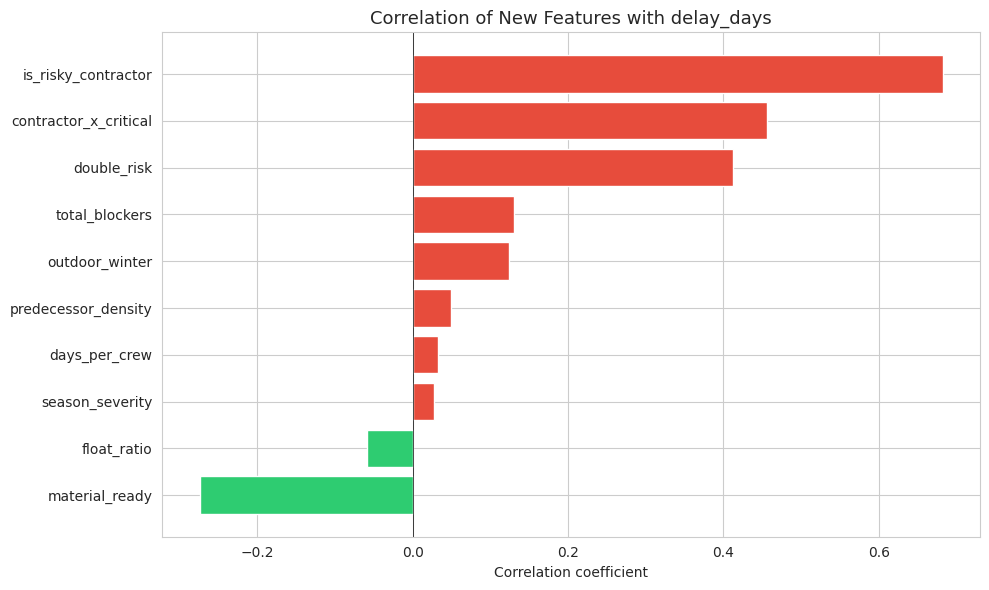


Most correlated new features:
is_risky_contractor     0.682
contractor_x_critical   0.457
double_risk             0.412
material_ready          0.274
total_blockers          0.130
Name: delay_days, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
new_feature_corr = df[new_features + ['delay_days']].corr()['delay_days'].drop('delay_days').sort_values()
colors = ['#E74C3C' if x > 0 else '#2ECC71' for x in new_feature_corr.values]
ax.barh(new_feature_corr.index, new_feature_corr.values, color=colors, edgecolor='white')
ax.set_title("Correlation of New Features with delay_days", fontsize=13)
ax.set_xlabel('Correlation coefficient')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nMost correlated new features:")
print(new_feature_corr.abs().sort_values(ascending=False).head(5).round(3))

In [12]:
# Low cardinality (≤5 unique) → One-Hot Encoding
# High cardinality (>5 unique) → Label Encoding

# Re-detect categorical columns (now including new features)
df_for_encoding = df.drop(columns=['task_id', 'activity_name',
                                    'planned_start', 'planned_finish', 'actual_finish_date',
                                    'delay_days', 'delay_category'])

cat_cols_v2, num_cols_v2, cat_but_car_v2 = grab_col_names(df_for_encoding)
print(f"\nCategorical: {cat_cols_v2}")
print(f"Cardinal: {cat_but_car_v2}")

Observations: 3565
Variables: 35
cat_cols: 23
num_cols: 11
cat_but_car: 1
num_but_cat: 15

Categorical: ['building', 'level', 'discipline', 'activity_type', 'contractor_id', 'contract_type', 'season', 'material_delivery_status', 'is_outdoor', 'is_critical_path', 'open_rfi_count', 'open_ncr_count', 'pending_submittal_count', 'lof_outlier_flag', 'planned_start_quarter', 'planned_start_year', 'planned_start_dayofweek', 'starts_on_monday', 'outdoor_winter', 'is_risky_contractor', 'double_risk', 'season_severity', 'material_ready']
Cardinal: ['axis']


In [13]:
def label_encoder(dataframe, binary_col):
    le = LabelEncoder()
    dataframe[binary_col] = le.fit_transform(dataframe[binary_col])
    return dataframe


# Helper: pandas v2+ compatible "is string" check
def is_string_col(s):
    return pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s)


# Binary columns (skip ones already 0/1; handle actual string ones)
binary_cols = [col for col in df.columns
               if is_string_col(df[col])
               and df[col].nunique() == 2]
print(f"Binary columns to label-encode: {binary_cols}")

for col in binary_cols:
    df = label_encoder(df, col)

Binary columns to label-encode: []


In [14]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first, dtype=int)
    return dataframe


# All string categorical columns except the target
ohe_cols = [col for col in df.columns
            if is_string_col(df[col])
            and col not in ['task_id', 'activity_name', 'delay_category']]
print(f"Columns to one-hot encode: {ohe_cols}")

df = one_hot_encoder(df, ohe_cols, drop_first=True)
print(f"\nNew DataFrame shape: {df.shape}")
print(f"Total columns: {df.shape[1]}")

Columns to one-hot encode: ['building', 'level', 'axis', 'discipline', 'activity_type', 'contractor_id', 'contract_type', 'season', 'material_delivery_status']

New DataFrame shape: (3565, 109)
Total columns: 109


In [15]:
# delay_category: On Time < Mild < Moderate < Severe (ordinal)
# Encoding in this order gives information to the model
category_order = {'On Time': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
df['delay_category_encoded'] = df['delay_category'].map(category_order)

print("Target encoding check:")
print(df[['delay_category', 'delay_category_encoded']].drop_duplicates().sort_values('delay_category_encoded'))

Target encoding check:
  delay_category  delay_category_encoded
0        On Time                       0
3           Mild                       1
2       Moderate                       2
5         Severe                       3


In [16]:
# Columns that should NOT be in the model:
# - ID and name columns
# - Date columns (already extracted month/quarter/dayofweek)
# - The target itself
# - actual_finish_date (data leakage — actual finish must not be present at prediction time)

drop_for_model = ['task_id', 'activity_name',
                  'planned_start', 'planned_finish', 'actual_finish_date',
                  'delay_category']  # encoded version is kept

# Targets
y_reg = df['delay_days']
y_clf = df['delay_category_encoded']

# Features (X)
X = df.drop(columns=drop_for_model + ['delay_days', 'delay_category_encoded'])

print(f"X shape: {X.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"y_clf shape: {y_clf.shape}")
print(f"\nFeature count: {X.shape[1]}")

X shape: (3565, 102)
y_reg shape: (3565,)
y_clf shape: (3565,)

Feature count: 102


In [17]:
# Stratify: stratified split based on the classification target
# (we use a common split for regression too, for a fair comparison)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf  # preserve class distribution
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

print("\nClass distribution check (train):")
print(y_clf_train.value_counts(normalize=True).round(3))
print("\nClass distribution check (test):")
print(y_clf_test.value_counts(normalize=True).round(3))

X_train: (2852, 102)
X_test:  (713, 102)

Class distribution check (train):
delay_category_encoded
0   0.377
1   0.338
2   0.175
3   0.110
Name: proportion, dtype: float64

Class distribution check (test):
delay_category_encoded
0   0.377
1   0.338
2   0.175
3   0.109
Name: proportion, dtype: float64


In [18]:
# We use RobustScaler because:
# - We didn't remove outliers; RobustScaler is based on median and IQR (outlier-resistant)
# - Tree-based models don't need scaling but it is required for linear/logistic baselines

# Only scale truly numerical columns (one-hot is already 0/1)
# Identify which columns are actually "numerical"
binary_or_int_cols = [col for col in X_train.columns
                       if X_train[col].nunique() <= 2 or X_train[col].dtype == 'int']

cols_to_scale = [col for col in X_train.columns if col not in binary_or_int_cols]
print(f"Columns to scale: {len(cols_to_scale)} columns")
print(cols_to_scale[:5], "...")

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\nScaling complete. Train shape: {X_train_scaled.shape}")

Columns to scale: 8 columns
['contractor_avg_delay_days', 'planned_start_month', 'planned_start_quarter', 'planned_start_dayofweek', 'contractor_x_critical'] ...

Scaling complete. Train shape: (2852, 102)


In [19]:
# Save both scaled and raw versions:
# - Tree-based models prefer raw data (scaling unnecessary)
# - Linear models require scaled data

processed = {
    'X_train': X_train,
    'X_test': X_test,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_reg_train': y_reg_train,
    'y_reg_test': y_reg_test,
    'y_clf_train': y_clf_train,
    'y_clf_test': y_clf_test,
    'feature_names': X.columns.tolist(),
    'scaled_columns': cols_to_scale,
    'category_mapping': category_order
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(processed, f)

print("✓ processed_data.pkl saved")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Total features: {len(X.columns)}")

✓ processed_data.pkl saved
  X_train: (2852, 102)
  X_test:  (713, 102)
  Total features: 102


In [20]:
print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)
print(f"""
What we did:
1. Outlier detection (IQR + LOF) → not removed, only flagged
2. 5 date features derived (month, quarter, year, dayofweek, monday)
3. 10 new interaction/derived features added
4. One-Hot Encoding for categorical → numerical conversion
5. Label encoding for the ordinal target (delay_category)
6. Train/test split (80/20 stratified)
7. RobustScaler scaling for {len(cols_to_scale)} numerical columns
8. Both scaled and raw versions saved as pickle

Final feature count: {X.shape[1]}
Total observations: {len(df):,}

Next step: 03_modeling.py
- Regression: Linear → CART → RF → LightGBM → XGBoost
- Classification: Logistic → CART → RF → LightGBM → XGBoost
- 5-fold cross-validation
- Hyperparameter optimization (GridSearchCV)
- Feature importance and SHAP analysis
""")

FEATURE ENGINEERING COMPLETED

What we did:
1. Outlier detection (IQR + LOF) → not removed, only flagged
2. 5 date features derived (month, quarter, year, dayofweek, monday)
3. 10 new interaction/derived features added
4. One-Hot Encoding for categorical → numerical conversion
5. Label encoding for the ordinal target (delay_category)
6. Train/test split (80/20 stratified)
7. RobustScaler scaling for 8 numerical columns
8. Both scaled and raw versions saved as pickle

Final feature count: 102
Total observations: 3,565

Next step: 03_modeling.py
- Regression: Linear → CART → RF → LightGBM → XGBoost
- Classification: Logistic → CART → RF → LightGBM → XGBoost
- 5-fold cross-validation
- Hyperparameter optimization (GridSearchCV)
- Feature importance and SHAP analysis

